# Complete Energy Efficiency Model Comparison
- Algorithm name
- Measured training time
- MAE, MSE, RMSE and R²
- Cross-validation mean and standard deviation
- Train–test gap
- Advantages, disadvantages and suitable use cases
It also includes residual analysis, learning curves, feature importance, SHAP explainability where supported, and an evidence-based final model selection.

In [10]:
from __future__ import annotations

import sys
import time
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, learning_curve

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
METRICS_DIR = PROJECT_ROOT / "outputs" / "metrics"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
CV_FOLDS = 5

from src.preprocessing import DataPreprocessor
from src.train import (
    MODEL_COMPLEXITY,
    _generalisation_status,
    _normalised_benefit,
    _normalised_cost,
    _stability_status,
    build_models,
)
from src.visualization import create_comparison_chart
from src.utils import load_json, load_model

print("Project-compatible imports completed successfully.")


Project-compatible imports completed successfully.


In [11]:
# LOAD THE EXACT TRAINING SPLIT AND MODEL DEFINITIONS
preprocessor = DataPreprocessor(
    target_col="Heating_Load",
    test_size=0.20,
    random_state=RANDOM_STATE,
    apply_feature_engineering=True,
    verbose=False,
)

X_train, X_test, y_train, y_test = (
    preprocessor.run_preprocessing_pipeline()
)

models = build_models()

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print(f"Final features: {X_train.columns.tolist()}")
print(f"Models configured: {len(models)}")


Train shape: (614, 8)
Test shape: (154, 8)
Final features: ['Relative_Compactness', 'Wall_Area', 'Roof_Area', 'Overall_Height', 'Orientation', 'Glazing_Area', 'Glazing_Area_Distribution', 'Compactness_Height']
Models configured: 12


In [12]:
# TRAIN, EVALUATE AND RANK ALL MODELS
cv = KFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

results = []
fitted_models = {}
predictions = {}
residuals = {}
failures = {}

for name, template in models.items():
    print(f"Training {name}...")
    try:
        fitted = clone(template)
        start = time.perf_counter()
        fitted.fit(X_train, y_train)
        training_time = time.perf_counter() - start

        pred_train = fitted.predict(X_train)
        pred_test = fitted.predict(X_test)

        cv_result = cross_validate(
            clone(template),
            X_train,
            y_train,
            cv=cv,
            scoring={
                "r2": "r2",
                "mae": "neg_mean_absolute_error",
                "rmse": "neg_root_mean_squared_error",
            },
            n_jobs=-1,
            error_score="raise",
        )

        train_mse = mean_squared_error(y_train, pred_train)
        test_mse = mean_squared_error(y_test, pred_test)
        train_r2 = r2_score(y_train, pred_train)
        test_r2 = r2_score(y_test, pred_test)

        results.append(
            {
                "Algorithm": name,
                "Training Time (s)": training_time,
                "Train MAE": mean_absolute_error(y_train, pred_train),
                "Train MSE": train_mse,
                "Train RMSE": np.sqrt(train_mse),
                "Train R2": train_r2,
                "MAE": mean_absolute_error(y_test, pred_test),
                "MSE": test_mse,
                "RMSE": np.sqrt(test_mse),
                "R2": test_r2,
                "Train-Test R2 Gap": train_r2 - test_r2,
                "CV R2 Mean": cv_result["test_r2"].mean(),
                "CV R2 Std": cv_result["test_r2"].std(),
                "CV MAE Mean": -cv_result["test_mae"].mean(),
                "CV RMSE Mean": -cv_result["test_rmse"].mean(),
            }
        )

        fitted_models[name] = fitted
        predictions[name] = np.asarray(pred_test)
        residuals[name] = np.asarray(y_test) - np.asarray(pred_test)

        print(
            f"  Test R²={test_r2:.5f} | "
            f"RMSE={np.sqrt(test_mse):.5f}"
        )

    except Exception as exc:
        failures[name] = str(exc)
        print(f"  FAILED: {exc}")

results_df = pd.DataFrame(results)
if results_df.empty:
    raise RuntimeError("No model trained successfully.")

results_df["Deployment Score"] = 100 * (
    0.40 * _normalised_benefit(results_df["R2"])
    + 0.15 * _normalised_cost(results_df["RMSE"])
    + 0.10 * _normalised_cost(results_df["MAE"])
    + 0.20 * _normalised_benefit(results_df["CV R2 Mean"])
    + 0.075 * _normalised_cost(results_df["CV R2 Std"])
    + 0.075 * _normalised_cost(
        results_df["Train-Test R2 Gap"].abs()
    )
)

results_df["Generalisation"] = (
    results_df["Train-Test R2 Gap"].map(_generalisation_status)
)
results_df["Stability"] = (
    results_df["CV R2 Std"].map(_stability_status)
)
results_df["Complexity"] = (
    results_df["Algorithm"].map(MODEL_COMPLEXITY).fillna("Unknown")
)

results_df = results_df.sort_values(
    ["Deployment Score", "R2", "RMSE"],
    ascending=[False, False, True],
).reset_index(drop=True)

results_df.insert(
    0,
    "Deployment Rank",
    np.arange(1, len(results_df) + 1),
)

comparison_path = METRICS_DIR / "model_comparison.csv"
ranking_path = METRICS_DIR / "deployment_ranking.csv"

results_df.to_csv(comparison_path, index=False)
results_df.to_csv(ranking_path, index=False)

display(
    results_df.style.format(
        {
            "Training Time (s)": "{:.5f}",
            "MAE": "{:.5f}",
            "MSE": "{:.5f}",
            "RMSE": "{:.5f}",
            "R2": "{:.5f}",
            "Train R2": "{:.5f}",
            "Train-Test R2 Gap": "{:.5f}",
            "CV R2 Mean": "{:.5f}",
            "CV R2 Std": "{:.5f}",
            "Deployment Score": "{:.2f}",
        }
    ).set_caption("Project-Compatible Model Comparison")
)

print(f"Saved: {comparison_path}")
print(f"Saved: {ranking_path}")


Training Linear Regression...


/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPi

  Test R²=0.91906 | RMSE=2.90465
Training Ridge Regression...


/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)


  Test R²=0.91237 | RMSE=3.02218
Training Lasso Regression...
  Test R²=0.91840 | RMSE=2.91643
Training Decision Tree...


...

  Test R²=0.99636 | RMSE=0.61635
Training Random Forest...
  Test R²=0.99769 | RMSE=0.49029
Training Gradient Boosting...
  Test R²=0.99759 | RMSE=0.50130
Training SVR...
  Test R²=0.99247 | RMSE=0.88608
Training Extra Trees...


/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)


  Test R²=0.99755 | RMSE=0.50485
Training AdaBoost...
  Test R²=0.95275 | RMSE=2.21912
Training XGBoost...
  Test R²=0.99862 | RMSE=0.37877
Training LightGBM...
  Test R²=0.99813 | RMSE=0.44092
Training CatBoost...
  Test R²=0.99880 | RMSE=0.35352


,Deployment Rank,Algorithm,Training Time (s),Train MAE,Train MSE,Train RMSE,Train R2,MAE,MSE,RMSE,R2,Train-Test R2 Gap,CV R2 Mean,CV R2 Std,CV MAE Mean,CV RMSE Mean,Deployment Score,Generalisation,Stability,Complexity
0,1,CatBoost,0.15204,0.129840,0.031293,0.176899,0.99969,0.25706,0.12498,0.35352,0.99880,0.00089,0.99859,0.00031,0.258184,0.373300,99.09,Strong,Very stable,High
1,2,XGBoost,0.31889,0.127450,0.033204,0.182219,0.99967,0.27379,0.14346,0.37877,0.99862,0.00105,0.99854,0.00023,0.257913,0.380620,98.59,Strong,Very stable,High
2,3,LightGBM,0.70876,0.253923,0.151027,0.388622,0.99850,0.32438,0.19441,0.44092,0.99813,0.00037,0.99693,0.00070,0.374660,0.552338,98.05,Strong,Very stable,High
3,4,Gradient Boosting,0.10719,0.257830,0.133601,0.365515,0.99868,0.36453,0.25130,0.50130,0.99759,0.00109,0.99785,0.00037,0.323780,0.462103,96.62,Strong,Very stable,High
4,5,Random Forest,0.16206,0.114676,0.030428,0.174437,0.99970,0.35331,0.24039,0.49029,0.99769,0.00200,0.99727,0.00033,0.345820,0.521399,95.29,Strong,Very stable,High
5,6,Extra Trees,0.09524,0.000049,0.000000,0.000480,1.00000,0.35050,0.25488,0.50485,0.99755,0.00245,0.99763,0.00014,0.322072,0.486924,94.72,Strong,Very stable,High
6,7,Decision Tree,0.00657,0.054885,0.022375,0.149584,0.99978,0.41686,0.37989,0.61635,0.99636,0.00342,0.99641,0.00075,0.386425,0.595219,90.98,Strong,Very stable,Medium
7,8,SVR,0.08198,0.471166,0.668969,0.817905,0.99337,0.65077,0.78513,0.88608,0.99247,0.00090,0.98110,0.00670,0.881021,1.349093,82.25,Strong,Stable,Medium
8,9,AdaBoost,0.29239,1.622408,4.283448,2.069649,0.95756,1.74133,4.92448,2.21912,0.95275,0.00480,0.95809,0.00704,1.614620,2.038212,39.06,Strong,Stable,Medium
9,10,Linear Regression,0.04207,2.063250,7.638158,2.763722,0.92432,2.15366,8.43701,2.90465,0.91906,0.00526,0.92203,0.00807,2.079858,2.788749,7.39,Strong,Stable,Low


Saved: /Users/sari/PythonProjects/energy-efficiency-prediction/outputs/metrics/model_comparison.csv
Saved: /Users/sari/PythonProjects/energy-efficiency-prediction/outputs/metrics/deployment_ranking.csv


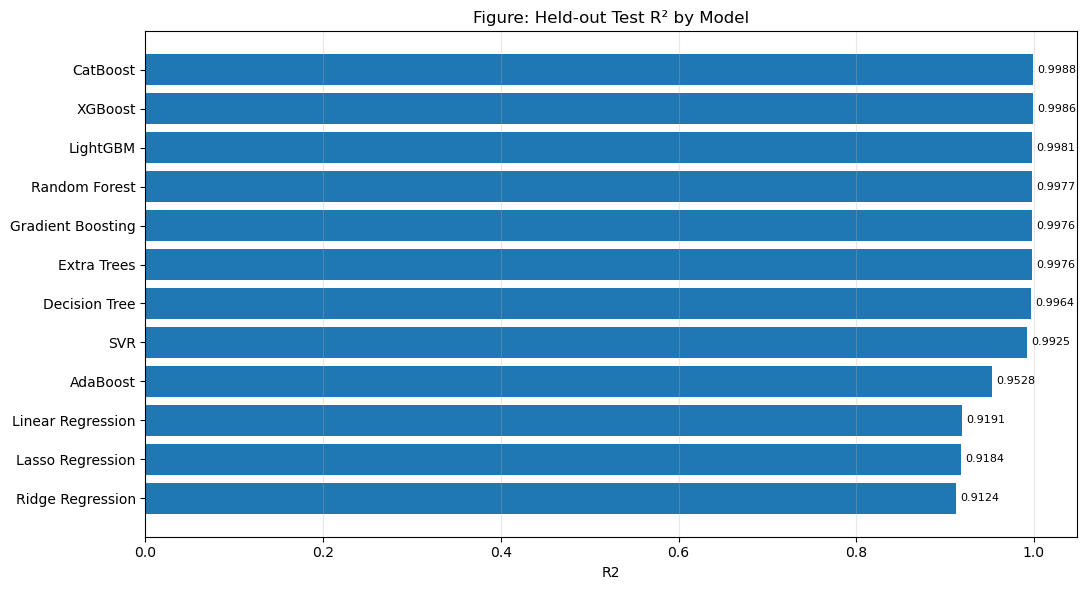

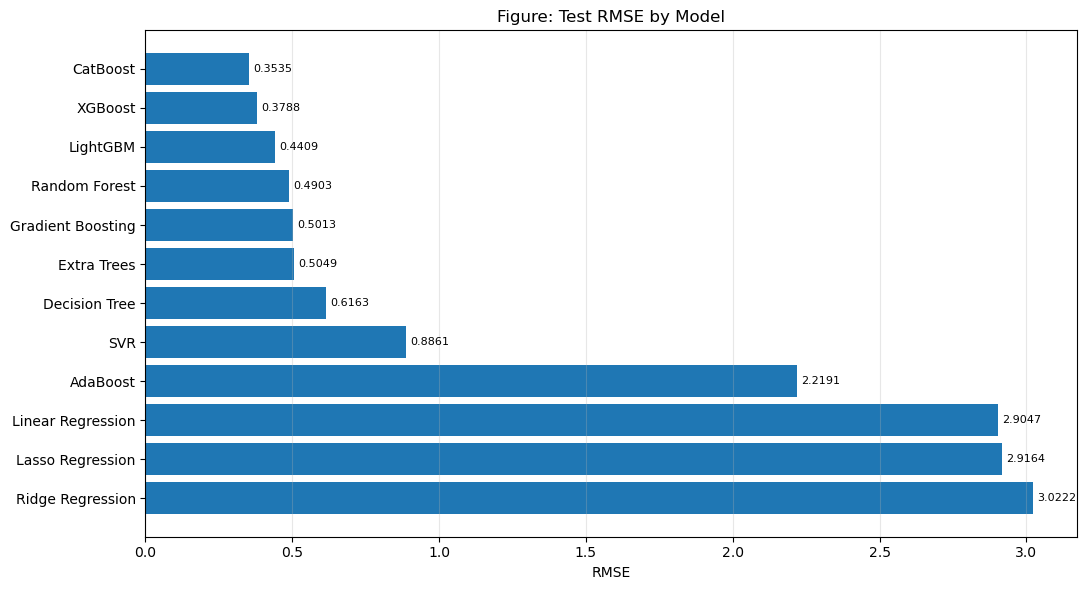

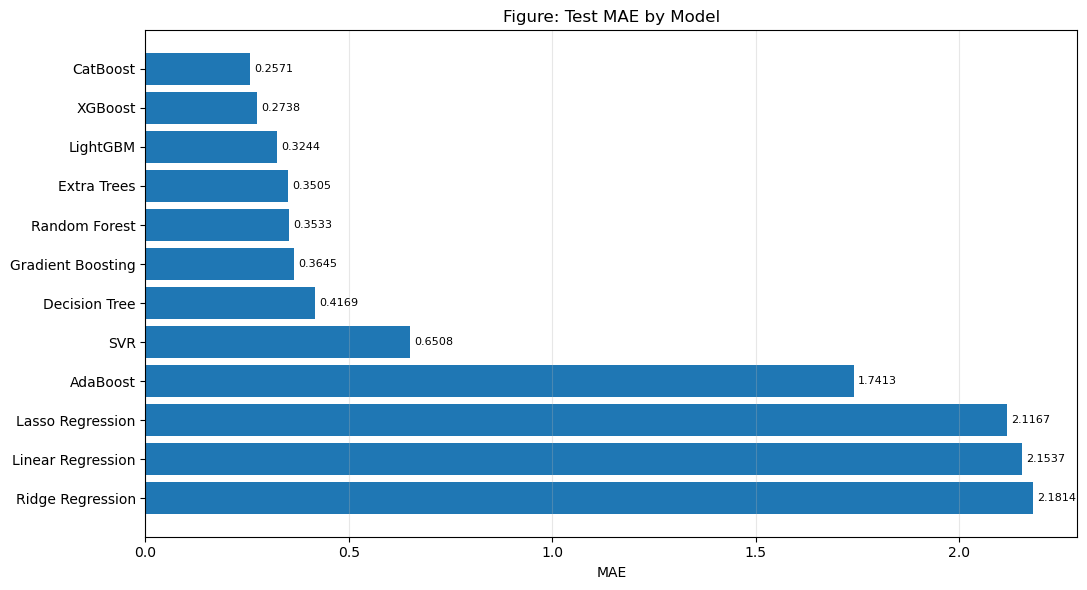

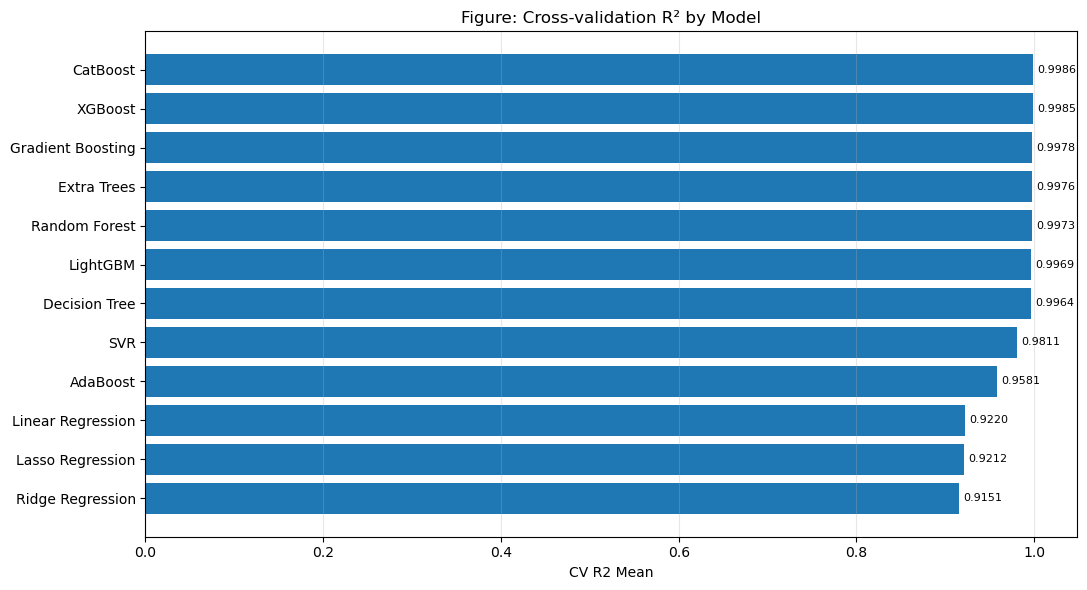

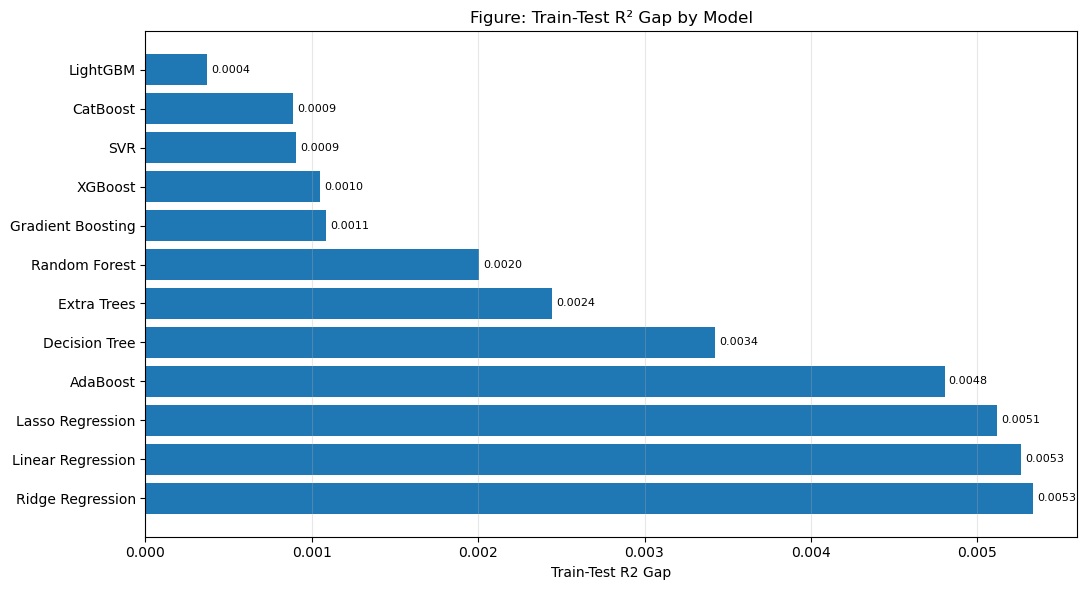

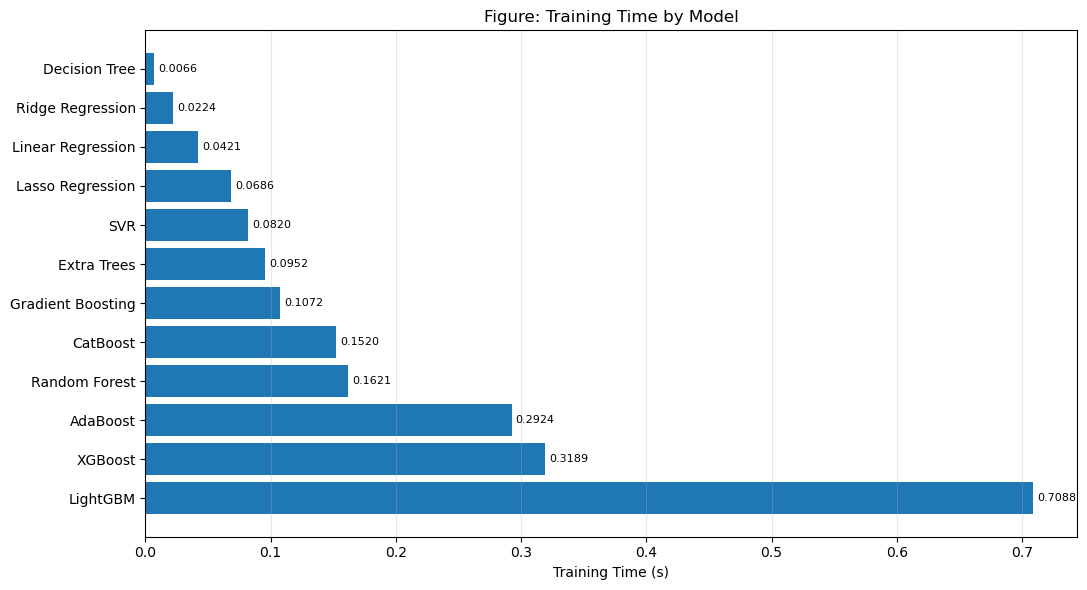

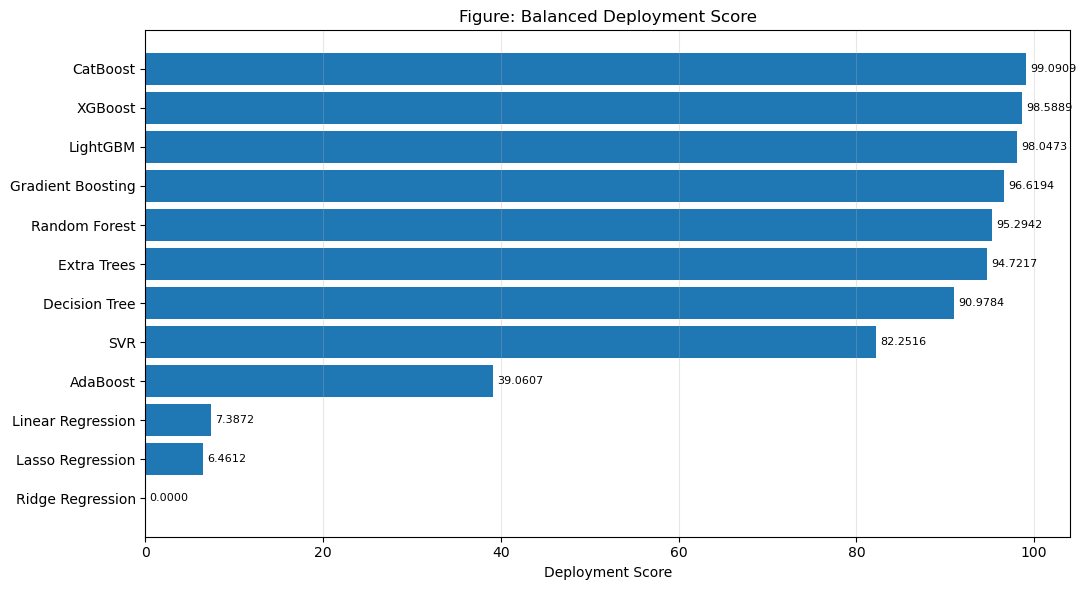

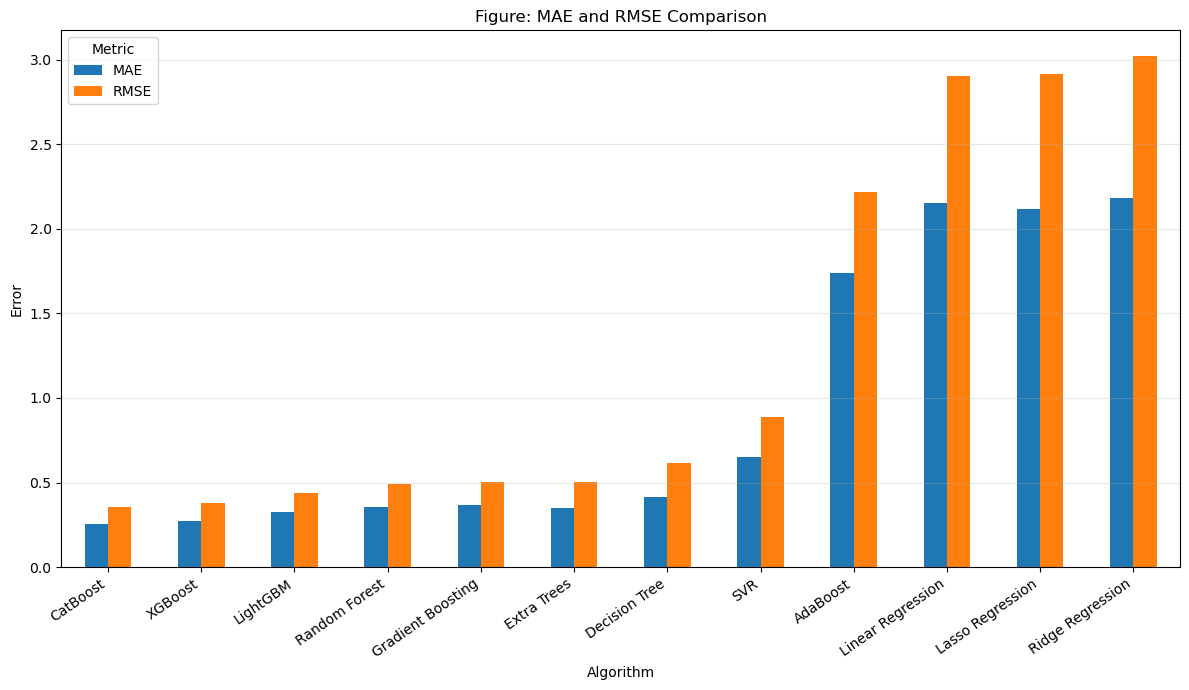

,Chart,Saved Path
0,R2,/Users/sari/PythonProjects/energy-efficiency-p...
1,RMSE,/Users/sari/PythonProjects/energy-efficiency-p...
2,MAE,/Users/sari/PythonProjects/energy-efficiency-p...
3,CV R2 Mean,/Users/sari/PythonProjects/energy-efficiency-p...
4,Train-Test R2 Gap,/Users/sari/PythonProjects/energy-efficiency-p...
5,Training Time (s),/Users/sari/PythonProjects/energy-efficiency-p...
6,Deployment Score,/Users/sari/PythonProjects/energy-efficiency-p...
7,error_comparison,/Users/sari/PythonProjects/energy-efficiency-p...


In [13]:
# SAVE CHECKLIST-ALIGNED COMPARISON FIGURES
figure_paths = create_comparison_chart(
    results_df,
    save=True,
    show=True,
)

display(
    pd.DataFrame(
        {
            "Chart": figure_paths.keys(),
            "Saved Path": [
                str(path) if path is not None else "Not saved"
                for path in figure_paths.values()
            ],
        }
    )
)


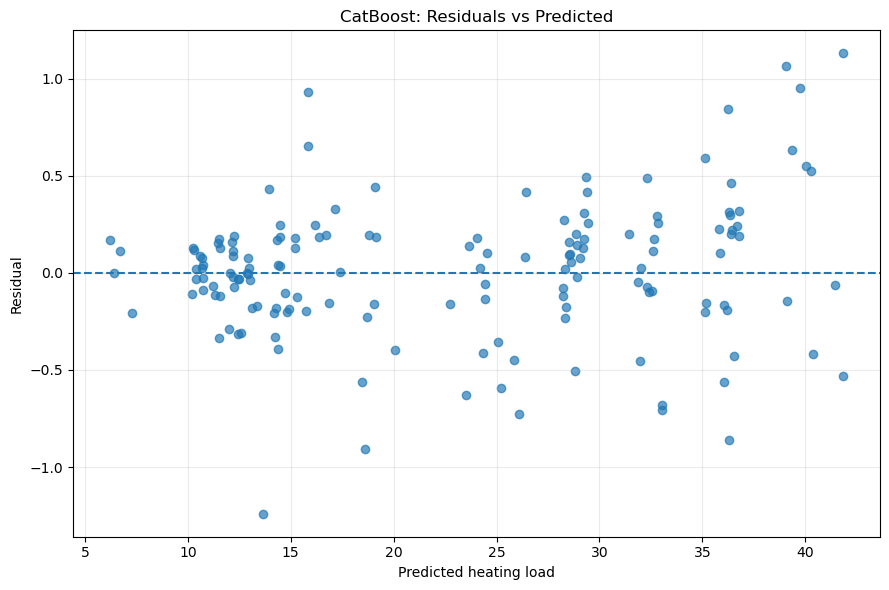

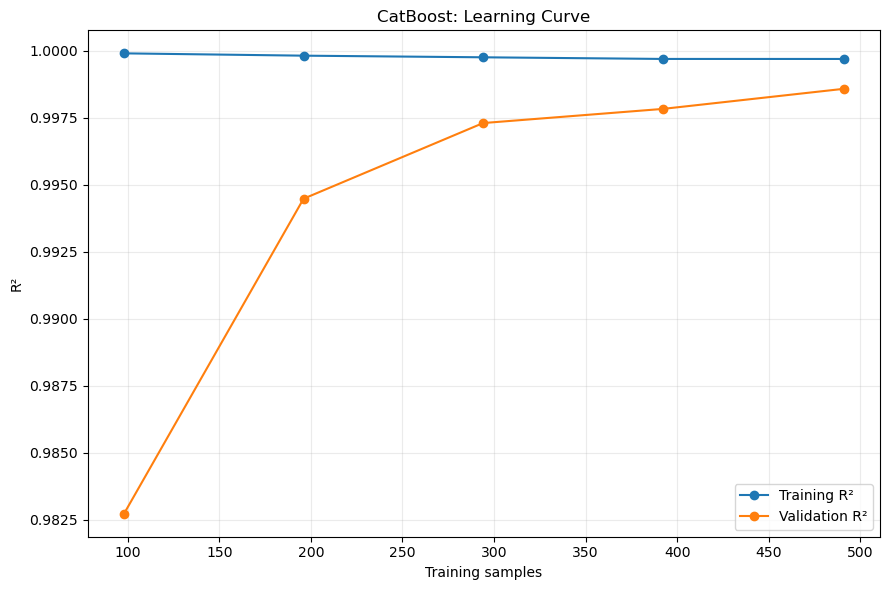

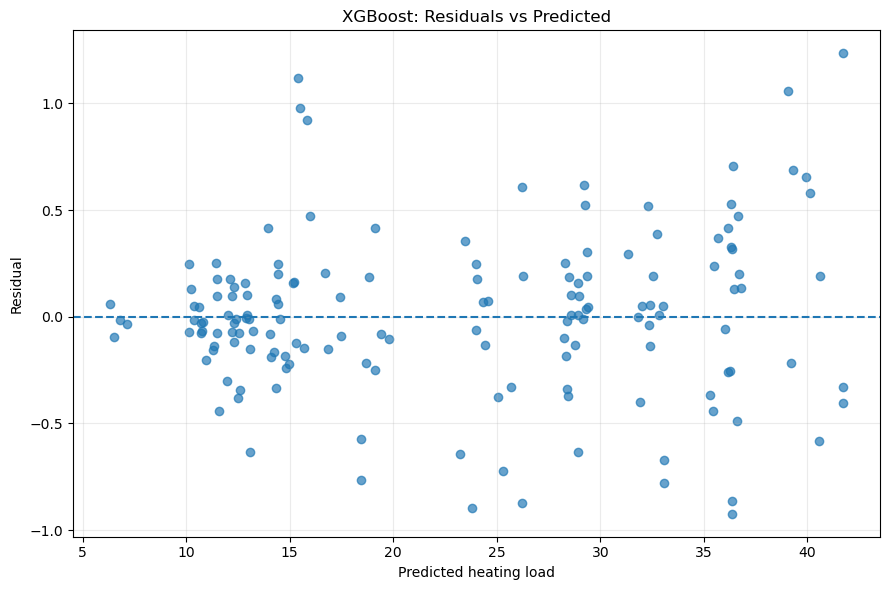

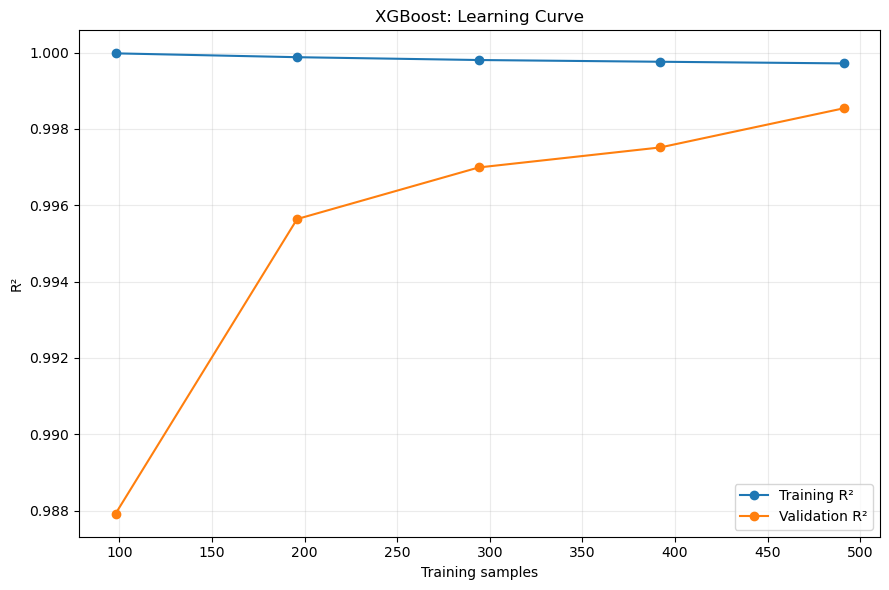

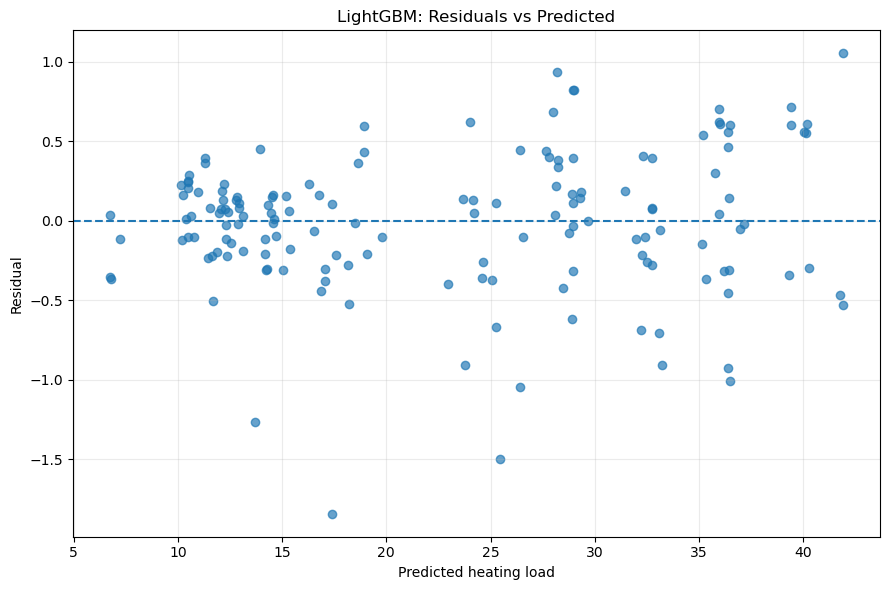

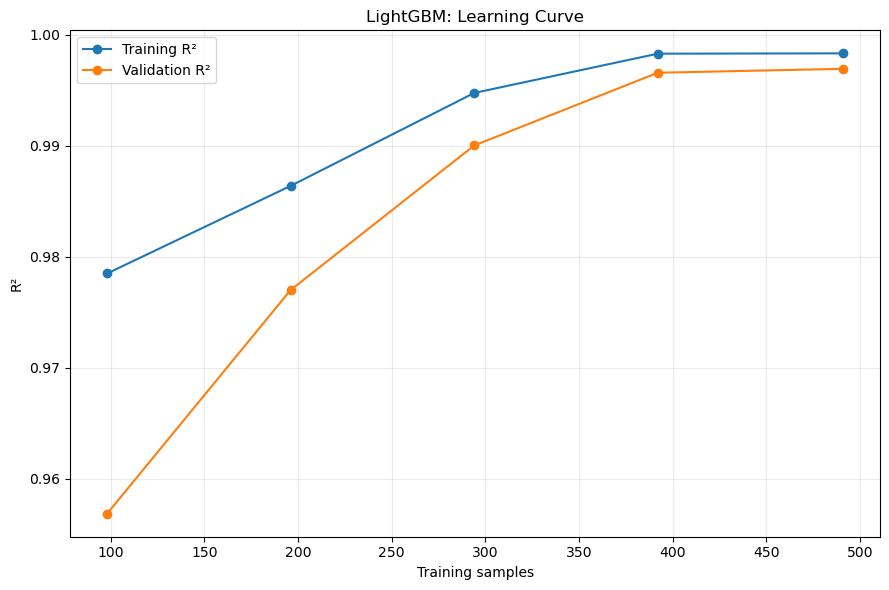

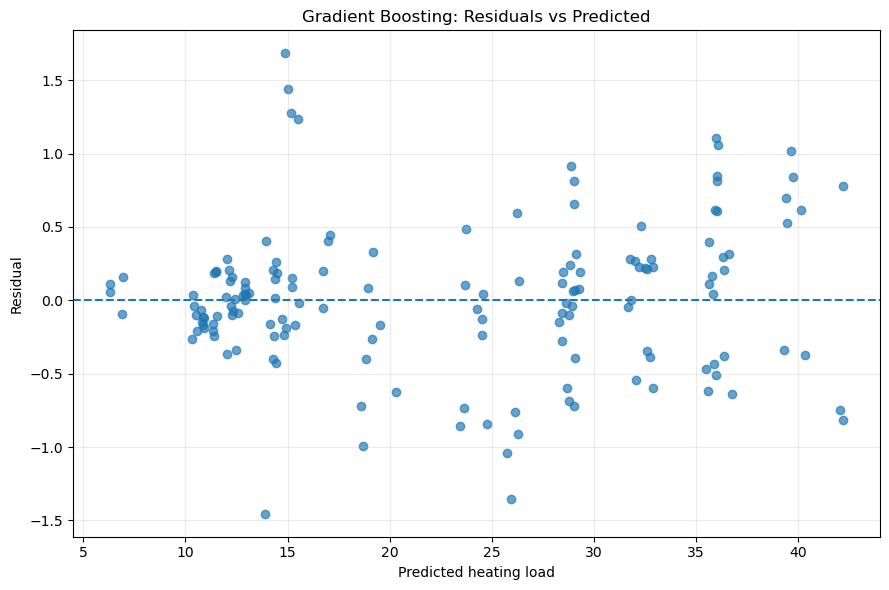

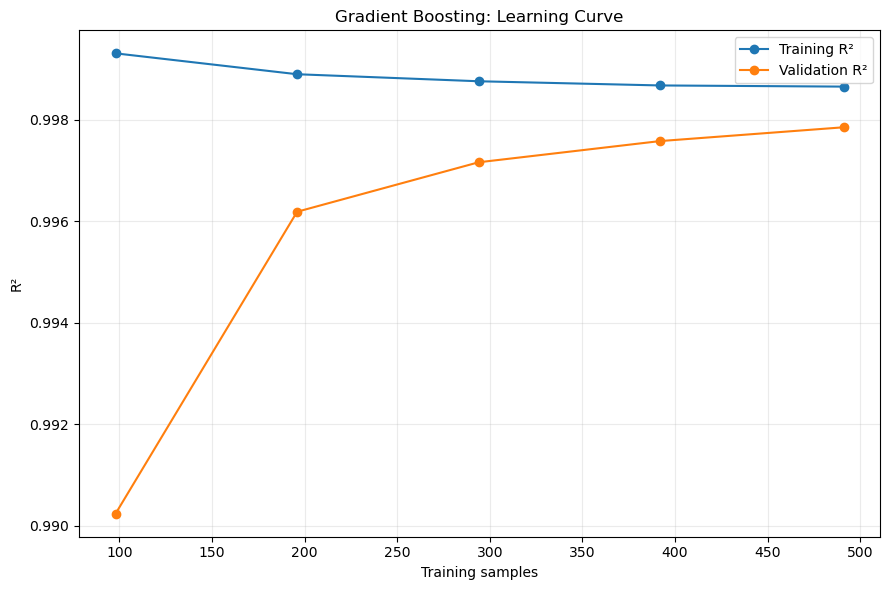

In [14]:
# RESIDUALS AND LEARNING CURVES FOR TOP FOUR DEPLOYMENT MODELS
top_models = results_df.head(4)["Algorithm"].tolist()

for name in top_models:
    safe = (
        name.lower()
        .replace(" ", "_")
        .replace("(", "")
        .replace(")", "")
    )
    pred = predictions[name]
    resid = residuals[name]

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.scatter(pred, resid, alpha=0.68)
    ax.axhline(0, linestyle="--")
    ax.set_title(f"{name}: Residuals vs Predicted")
    ax.set_xlabel("Predicted heating load")
    ax.set_ylabel("Residual")
    ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(
        FIGURES_DIR / f"{safe}_residuals.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

    sizes, train_scores, validation_scores = learning_curve(
        clone(models[name]),
        X_train,
        y_train,
        train_sizes=np.linspace(0.20, 1.00, 5),
        cv=cv,
        scoring="r2",
        n_jobs=-1,
    )

    train_mean = train_scores.mean(axis=1)
    validation_mean = validation_scores.mean(axis=1)

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.plot(sizes, train_mean, marker="o", label="Training R²")
    ax.plot(
        sizes,
        validation_mean,
        marker="o",
        label="Validation R²",
    )
    ax.set_title(f"{name}: Learning Curve")
    ax.set_xlabel("Training samples")
    ax.set_ylabel("R²")
    ax.legend()
    ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(
        FIGURES_DIR / f"{safe}_learning_curve.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


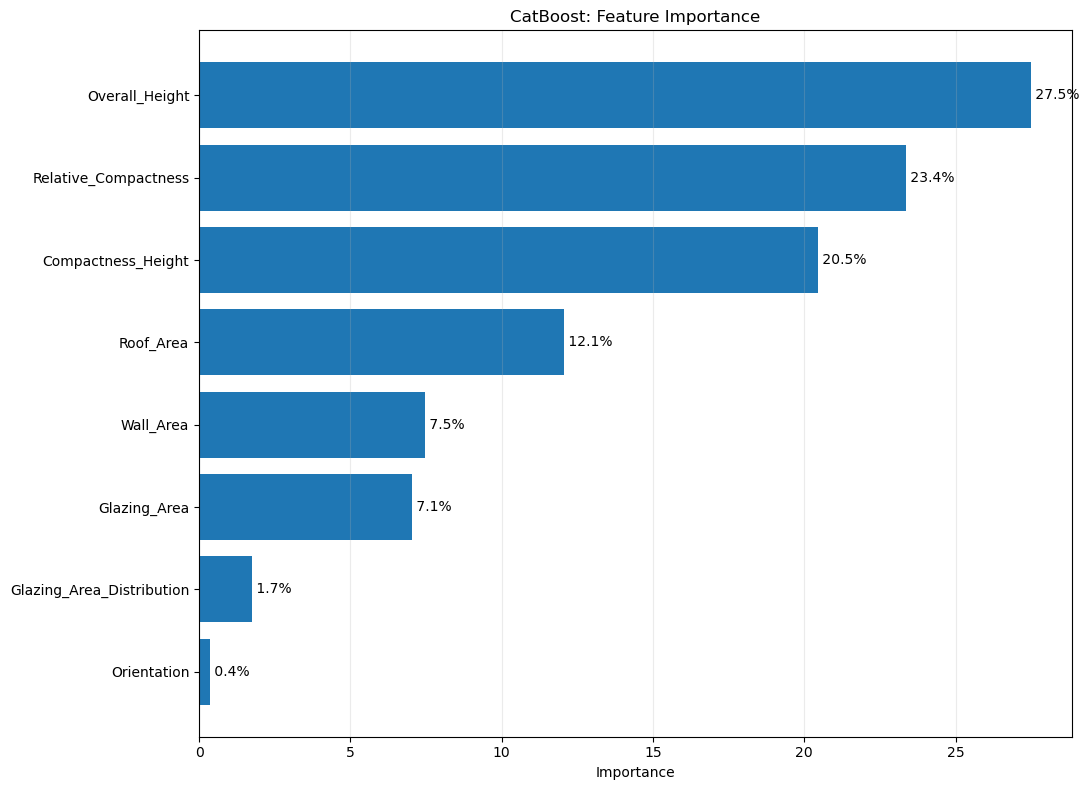

,Feature,Importance,Percentage
3,Overall_Height,27.47814,27.47814
0,Relative_Compactness,23.36761,23.36761
7,Compactness_Height,20.46334,20.46334
2,Roof_Area,12.06428,12.06428
1,Wall_Area,7.45763,7.45763
5,Glazing_Area,7.05273,7.05273
6,Glazing_Area_Distribution,1.74167,1.74167
4,Orientation,0.37460,0.37460


In [15]:
# FEATURE IMPORTANCE OR COEFFICIENT ANALYSIS
importance_tables = {}

for name, pipeline in fitted_models.items():
    estimator = pipeline.named_steps["model"]

    if hasattr(estimator, "feature_importances_"):
        values = np.asarray(
            estimator.feature_importances_,
            dtype=float,
        )
    elif hasattr(estimator, "coef_"):
        values = np.abs(
            np.asarray(estimator.coef_, dtype=float).ravel()
        )
    else:
        continue

    if len(values) != len(X_train.columns):
        continue

    table = pd.DataFrame(
        {
            "Feature": X_train.columns,
            "Importance": values,
        }
    ).sort_values("Importance", ascending=False)

    total = table["Importance"].sum()
    table["Percentage"] = (
        table["Importance"] / total * 100
        if total > 0
        else 0
    )
    importance_tables[name] = table

importance_model = next(
    (
        name
        for name in results_df["Algorithm"]
        if name in importance_tables
    ),
    None,
)

if importance_model:
    table = importance_tables[importance_model]
    top = table.head(15).sort_values("Importance")

    fig, ax = plt.subplots(figsize=(11, 8))
    bars = ax.barh(top["Feature"], top["Importance"])
    ax.set_title(f"{importance_model}: Feature Importance")
    ax.set_xlabel("Importance")
    ax.grid(axis="x", alpha=0.25)

    for bar, percentage in zip(bars, top["Percentage"]):
        ax.text(
            bar.get_width(),
            bar.get_y() + bar.get_height() / 2,
            f" {percentage:.1f}%",
            va="center",
        )

    fig.tight_layout()
    fig.savefig(
        FIGURES_DIR / "best_supported_model_feature_importance.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

    display(table.head(15).round(5))
else:
    print("No fitted model exposes direct importance or coefficients.")


In [16]:
# SHAP EXPLAINABILITY FOR THE DEPLOYMENT WINNER
import shap

best_name = results_df.iloc[0]["Algorithm"]
best_pipeline = fitted_models[best_name]
preprocessing_step = best_pipeline.named_steps["preprocessing"]
estimator = best_pipeline.named_steps["model"]

background_raw = X_train.sample(
    min(100, len(X_train)),
    random_state=RANDOM_STATE,
)
explain_raw = X_test.sample(
    min(100, len(X_test)),
    random_state=RANDOM_STATE,
)

background = preprocessing_step.transform(background_raw)
explain_data = preprocessing_step.transform(explain_raw)

try:
    explainer = shap.Explainer(estimator, background)
    shap_values = explainer(explain_data)

    shap.summary_plot(
        shap_values,
        explain_data,
        feature_names=list(X_train.columns),
        show=False,
    )
    plt.title(f"{best_name}: SHAP Summary")
    plt.tight_layout()
    plt.savefig(
        FIGURES_DIR / "best_model_shap_summary.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

    shap.summary_plot(
        shap_values,
        explain_data,
        feature_names=list(X_train.columns),
        plot_type="bar",
        show=False,
    )
    plt.title(f"{best_name}: SHAP Global Importance")
    plt.tight_layout()
    plt.savefig(
        FIGURES_DIR / "best_model_shap_bar.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

except Exception as exc:
    print(f"SHAP was not available directly for {best_name}: {exc}")


SHAP was not available directly for CatBoost: The passed model is not callable and cannot be analyzed directly with the given masker! Model: CatBoostSklearnAdapter()


In [17]:
model_knowledge = {
    "Linear Regression": (
        "Fast, simple and interpretable.",
        "Assumes linear relationships and may underfit.",
        "Baselines and explanation-focused linear problems.",
    ),
    "Ridge Regression": (
        "Handles correlated predictors and stabilises coefficients.",
        "Still linear and does not remove features.",
        "Regularised linear regression with correlated inputs.",
    ),
    "Lasso Regression": (
        "Can remove weak features through coefficient shrinkage.",
        "May remove useful correlated features and remains linear.",
        "Sparse linear models and feature selection.",
    ),
    "Decision Tree": (
        "Captures nonlinear relationships and produces explainable rules.",
        "High variance and prone to overfitting.",
        "Explainable nonlinear baselines.",
    ),
    "Random Forest": (
        "Robust ensemble that captures interactions and nonlinearities.",
        "Uses more memory and is less interpretable.",
        "Strong general-purpose tabular regression.",
    ),
    "Gradient Boosting": (
        "Sequential error correction often gives strong accuracy.",
        "Sensitive to tuning and may train slowly.",
        "Structured data where accuracy matters.",
    ),
    "SVR": (
        "Flexible nonlinear kernels for smaller datasets.",
        "Sensitive to scaling and hyperparameters.",
        "Small or medium scaled nonlinear datasets.",
    ),
    "XGBoost": (
        "Regularised boosting with strong tabular accuracy.",
        "Complex tuning and potentially higher training cost.",
        "High-accuracy tabular prediction.",
    ),
    "Extra Trees": (
        "Fast randomised ensemble with strong nonlinear modelling.",
        "Less interpretable and may use significant memory.",
        "Fast ensemble baselines.",
    ),
    "AdaBoost": (
        "Focuses on difficult observations.",
        "Sensitive to noise and often weaker than modern boosting.",
        "Small datasets and educational boosting comparisons.",
    ),
    "CatBoost": (
        "Strong defaults and excellent tabular performance.",
        "Can train slowly and is less transparent.",
        "High-quality tabular prediction, especially with categories.",
    ),
    "LightGBM": (
        "Fast, memory-efficient and accurate on tabular data.",
        "Leaf-wise growth can overfit small data.",
        "Production systems needing accuracy and speed.",
    ),
}

required_columns = {
    "Algorithm",
    "R2",
    "RMSE",
    "MAE",
    "Train-Test R2 Gap",
}

missing_columns = required_columns.difference(results_df.columns)

if missing_columns:
    raise ValueError(
        "results_df is missing required columns: "
        + ", ".join(sorted(missing_columns))
        + f"\nAvailable columns: {results_df.columns.tolist()}"
    )

best_r2 = results_df["R2"].max()
rows = []

for _, row in results_df.iterrows():
    name = row["Algorithm"]

    advantage, disadvantage, use_case = model_knowledge.get(
        name,
        (
            "Useful regression model.",
            "Performance depends on data and tuning.",
            "General regression comparison.",
        ),
    )

    if row["R2"] >= best_r2 - 0.001:
        evidence = (
            f"Top-tier: R²={row['R2']:.4f}, "
            f"RMSE={row['RMSE']:.4f}, "
            f"MAE={row['MAE']:.4f}."
        )
    elif row["R2"] >= 0.98:
        evidence = (
            f"Strong but below leaders: "
            f"R²={row['R2']:.4f}, "
            f"RMSE={row['RMSE']:.4f}, "
            f"MAE={row['MAE']:.4f}."
        )
    else:
        evidence = (
            f"Lower fit: "
            f"R²={row['R2']:.4f}, "
            f"RMSE={row['RMSE']:.4f}, "
            f"MAE={row['MAE']:.4f}."
        )

    gap = abs(float(row["Train-Test R2 Gap"]))

    if gap > 0.02:
        evidence += (
            f" Train-test gap={gap:.4f}, "
            "suggesting possible overfitting."
        )
    else:
        evidence += (
            f" Train-test gap={gap:.4f}, "
            "indicating good generalisation."
        )

    if "CV R2 Mean" in results_df.columns:
        evidence += f" CV R²={row['CV R2 Mean']:.4f}."

    if "Deployment Score" in results_df.columns:
        evidence += (
            f" Deployment score={row['Deployment Score']:.2f}/100."
        )

    rows.append(
        {
            "Algorithm": name,
            "Advantages": advantage,
            "Disadvantages": disadvantage,
            "Suitable Use Cases": use_case,
            "Evidence from Metrics": evidence,
        }
    )

analysis_df = pd.DataFrame(rows)

display(
    analysis_df.style.set_properties(
        **{
            "text-align": "left",
            "white-space": "normal",
        }
    ).set_caption("Algorithm Discussion")
)

analysis_path = METRICS_DIR / "model_analysis.csv"
analysis_df.to_csv(analysis_path, index=False)

print(f"Saved: {analysis_path}")

,Algorithm,Advantages,Disadvantages,Suitable Use Cases,Evidence from Metrics
0,CatBoost,Strong defaults and excellent tabular performance.,Can train slowly and is less transparent.,"High-quality tabular prediction, especially with categories.","Top-tier: R²=0.9988, RMSE=0.3535, MAE=0.2571. Train-test gap=0.0009, indicating good generalisation. CV R²=0.9986. Deployment score=99.09/100."
1,XGBoost,Regularised boosting with strong tabular accuracy.,Complex tuning and potentially higher training cost.,High-accuracy tabular prediction.,"Top-tier: R²=0.9986, RMSE=0.3788, MAE=0.2738. Train-test gap=0.0010, indicating good generalisation. CV R²=0.9985. Deployment score=98.59/100."
2,LightGBM,"Fast, memory-efficient and accurate on tabular data.",Leaf-wise growth can overfit small data.,Production systems needing accuracy and speed.,"Top-tier: R²=0.9981, RMSE=0.4409, MAE=0.3244. Train-test gap=0.0004, indicating good generalisation. CV R²=0.9969. Deployment score=98.05/100."
3,Gradient Boosting,Sequential error correction often gives strong accuracy.,Sensitive to tuning and may train slowly.,Structured data where accuracy matters.,"Strong but below leaders: R²=0.9976, RMSE=0.5013, MAE=0.3645. Train-test gap=0.0011, indicating good generalisation. CV R²=0.9978. Deployment score=96.62/100."
4,Random Forest,Robust ensemble that captures interactions and nonlinearities.,Uses more memory and is less interpretable.,Strong general-purpose tabular regression.,"Strong but below leaders: R²=0.9977, RMSE=0.4903, MAE=0.3533. Train-test gap=0.0020, indicating good generalisation. CV R²=0.9973. Deployment score=95.29/100."
5,Extra Trees,Fast randomised ensemble with strong nonlinear modelling.,Less interpretable and may use significant memory.,Fast ensemble baselines.,"Strong but below leaders: R²=0.9976, RMSE=0.5049, MAE=0.3505. Train-test gap=0.0024, indicating good generalisation. CV R²=0.9976. Deployment score=94.72/100."
6,Decision Tree,Captures nonlinear relationships and produces explainable rules.,High variance and prone to overfitting.,Explainable nonlinear baselines.,"Strong but below leaders: R²=0.9964, RMSE=0.6163, MAE=0.4169. Train-test gap=0.0034, indicating good generalisation. CV R²=0.9964. Deployment score=90.98/100."
7,SVR,Flexible nonlinear kernels for smaller datasets.,Sensitive to scaling and hyperparameters.,Small or medium scaled nonlinear datasets.,"Strong but below leaders: R²=0.9925, RMSE=0.8861, MAE=0.6508. Train-test gap=0.0009, indicating good generalisation. CV R²=0.9811. Deployment score=82.25/100."
8,AdaBoost,Focuses on difficult observations.,Sensitive to noise and often weaker than modern boosting.,Small datasets and educational boosting comparisons.,"Lower fit: R²=0.9528, RMSE=2.2191, MAE=1.7413. Train-test gap=0.0048, indicating good generalisation. CV R²=0.9581. Deployment score=39.06/100."
9,Linear Regression,"Fast, simple and interpretable.",Assumes linear relationships and may underfit.,Baselines and explanation-focused linear problems.,"Lower fit: R²=0.9191, RMSE=2.9047, MAE=2.1537. Train-test gap=0.0053, indicating good generalisation. CV R²=0.9220. Deployment score=7.39/100."


Saved: /Users/sari/PythonProjects/energy-efficiency-prediction/outputs/metrics/model_analysis.csv


In [18]:
# EVIDENCE-BASED FINAL SELECTION
deployment_winner = results_df.iloc[0]
runner_up = results_df.iloc[1] if len(results_df) > 1 else None

lines = [
    "# Final Model Selection",
    "",
    f"**Selected model:** {deployment_winner['Algorithm']}",
    "",
    (
        f"Deployment score: "
        f"{deployment_winner['Deployment Score']:.2f}/100"
    ),
    (
        f"Test R²: {deployment_winner['R2']:.5f}; "
        f"RMSE: {deployment_winner['RMSE']:.5f}; "
        f"MAE: {deployment_winner['MAE']:.5f}"
    ),
    (
        f"CV R²: {deployment_winner['CV R2 Mean']:.5f} "
        f"± {deployment_winner['CV R2 Std']:.5f}"
    ),
    (
        f"Train-test gap: "
        f"{deployment_winner['Train-Test R2 Gap']:.5f}"
    ),
    (
        f"Generalisation: "
        f"{deployment_winner['Generalisation']}; "
        f"Stability: {deployment_winner['Stability']}"
    ),
    "",
    (
        "The model was selected using the same balanced deployment "
        "score as src/train.py. The decision does not rely on R² alone."
    ),
]

if runner_up is not None:
    lines.extend(
        [
            "",
            (
                f"Runner-up: **{runner_up['Algorithm']}** with score "
                f"{runner_up['Deployment Score']:.2f}/100."
            ),
        ]
    )

lines.extend(
    [
        "",
        "R² is not literal percentage accuracy; it measures explained "
        "variation on the evaluated data.",
    ]
)

display(Markdown("\n".join(lines)))

display(
    results_df[
        [
            "Deployment Rank",
            "Algorithm",
            "Deployment Score",
            "R2",
            "RMSE",
            "MAE",
            "CV R2 Mean",
            "CV R2 Std",
            "Train-Test R2 Gap",
            "Generalisation",
            "Stability",
            "Complexity",
        ]
    ].style.format(
        {
            "Deployment Score": "{:.2f}",
            "R2": "{:.5f}",
            "RMSE": "{:.5f}",
            "MAE": "{:.5f}",
            "CV R2 Mean": "{:.5f}",
            "CV R2 Std": "{:.5f}",
            "Train-Test R2 Gap": "{:.5f}",
        }
    ).set_caption("Balanced Deployment Ranking")
)

print("MODEL COMPARISON COMPLETED SUCCESSFULLY")
print(f"Deployment winner: {deployment_winner['Algorithm']}")
print(f"Comparison CSV: {comparison_path}")
print(f"Deployment CSV: {ranking_path}")
print(f"Figures: {FIGURES_DIR}")


# Final Model Selection

**Selected model:** CatBoost

Deployment score: 99.09/100
Test R²: 0.99880; RMSE: 0.35352; MAE: 0.25706
CV R²: 0.99859 ± 0.00031
Train-test gap: 0.00089
Generalisation: Strong; Stability: Very stable

The model was selected using the same balanced deployment score as src/train.py. The decision does not rely on R² alone.

Runner-up: **XGBoost** with score 98.59/100.

R² is not literal percentage accuracy; it measures explained variation on the evaluated data.

,Deployment Rank,Algorithm,Deployment Score,R2,RMSE,MAE,CV R2 Mean,CV R2 Std,Train-Test R2 Gap,Generalisation,Stability,Complexity
0,1,CatBoost,99.09,0.99880,0.35352,0.25706,0.99859,0.00031,0.00089,Strong,Very stable,High
1,2,XGBoost,98.59,0.99862,0.37877,0.27379,0.99854,0.00023,0.00105,Strong,Very stable,High
2,3,LightGBM,98.05,0.99813,0.44092,0.32438,0.99693,0.00070,0.00037,Strong,Very stable,High
3,4,Gradient Boosting,96.62,0.99759,0.50130,0.36453,0.99785,0.00037,0.00109,Strong,Very stable,High
4,5,Random Forest,95.29,0.99769,0.49029,0.35331,0.99727,0.00033,0.00200,Strong,Very stable,High
5,6,Extra Trees,94.72,0.99755,0.50485,0.35050,0.99763,0.00014,0.00245,Strong,Very stable,High
6,7,Decision Tree,90.98,0.99636,0.61635,0.41686,0.99641,0.00075,0.00342,Strong,Very stable,Medium
7,8,SVR,82.25,0.99247,0.88608,0.65077,0.98110,0.00670,0.00090,Strong,Stable,Medium
8,9,AdaBoost,39.06,0.95275,2.21912,1.74133,0.95809,0.00704,0.00480,Strong,Stable,Medium
9,10,Linear Regression,7.39,0.91906,2.90465,2.15366,0.92203,0.00807,0.00526,Strong,Stable,Low


MODEL COMPARISON COMPLETED SUCCESSFULLY
Deployment winner: CatBoost
Comparison CSV: /Users/sari/PythonProjects/energy-efficiency-prediction/outputs/metrics/model_comparison.csv
Deployment CSV: /Users/sari/PythonProjects/energy-efficiency-prediction/outputs/metrics/deployment_ranking.csv
Figures: /Users/sari/PythonProjects/energy-efficiency-prediction/outputs/figures


In [19]:
# PRODUCTION COMPATIBILITY CHECK
# src/train.py is the only authoritative file that saves best_model.pkl,
# model_metadata.json and feature_info.json. This notebook is analysis-only.

model_path = PROJECT_ROOT / "models" / "best_model.pkl"
metadata_path = PROJECT_ROOT / "models" / "model_metadata.json"

if model_path.exists() and metadata_path.exists():
    saved_model = load_model("best_model.pkl")
    saved_metadata = load_json(
        "model_metadata.json",
        required=True,
    )

    print(f"Saved production model: {saved_metadata['best_model']}")
    print(f"Notebook deployment winner: {deployment_winner['Algorithm']}")

    if saved_metadata["best_model"] != deployment_winner["Algorithm"]:
        print(
            "The notebook and saved model differ. Run "
            "`python -m src.train` to refresh authoritative artefacts."
        )
    else:
        print("Notebook results match the saved production model.")
else:
    print(
        "Production artefacts are unavailable. Run "
        "`python -m src.train`."
    )


Saved production model: CatBoost
Notebook deployment winner: CatBoost
Notebook results match the saved production model.
